In [ ]:
!pip install opencv-python albumentations segmentation-models-pytorch

In [ ]:
!unzip -q DogEyeSeg4_dataset.zip

## 1. Imports and Setup

In [21]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# Path configuration
DATASET_ROOT = "DogEyeSeg4_dataset"
IMAGES_DIR = os.path.join(DATASET_ROOT, "Images")
MASKS_DIR = os.path.join(DATASET_ROOT, "Masks", "Gray")

CLASS_NAMES = ["Background", "Corneal Edema", "Episcleral Congestion", "Epiphora", "Cherry Eye"]
NUM_CLASSES = len(CLASS_NAMES)  # 5

# Official RGB palette for color visualization
COLOR_PALETTE = {
    0: [0, 38, 255],     # Background (Blue)
    1: [0, 148, 255],    # Corneal edema (Light blue)
    2: [76, 255, 0],     # Episcleral congestion (Green)
    3: [255, 106, 0],    # Epiphora (Orange)
    4: [255, 0, 110]     # Cherry Eye (Pink/Magenta)
}

Executing on: cuda


## 2. Train/Val/Test Split & Dataset Augmentation

In [22]:
all_image_names = sorted([
    f for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg')) and os.path.exists(os.path.join(MASKS_DIR, f))
])
print(f"Total matching images found: {len(all_image_names)}")

# 70/15/15 split
train_files, temp_files = train_test_split(all_image_names, test_size=0.30, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

print(f"Train samples: {len(train_files)} | Val samples: {len(val_files)} | Test samples: {len(test_files)}")

# Augmenting dataset (horizontal flip, small rotation augmentation)
def get_transforms(img_size=224, is_train=True):
    if is_train:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.Affine(
                scale=(0.92, 1.08),
                translate_percent=(-0.04, 0.04),
                rotate=(-10, 10),
                interpolation=cv2.INTER_LINEAR,
                mask_interpolation=cv2.INTER_NEAREST,
                p=0.5,
            ),
            # Only mild brightness/contrast, no hue shift
            A.RandomBrightnessContrast(
                brightness_limit=0.1,
                contrast_limit=0.1,
                p=0.5
            ),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


class DogEyeSeg4Dataset(Dataset):
    def __init__(self, file_list, images_dir, masks_dir, transform=None):
        self.file_list = file_list
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        img_path = os.path.join(self.images_dir, file_name)
        mask_path = os.path.join(self.masks_dir, file_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

train_loader = DataLoader(
    DogEyeSeg4Dataset(train_files, IMAGES_DIR, MASKS_DIR, transform=get_transforms(320, is_train=True)),
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    DogEyeSeg4Dataset(val_files, IMAGES_DIR, MASKS_DIR, transform=get_transforms(320, is_train=False)),
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    DogEyeSeg4Dataset(test_files, IMAGES_DIR, MASKS_DIR, transform=get_transforms(320, is_train=False)),
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

Total matching images found: 145
Train samples: 101 | Val samples: 22 | Test samples: 22


## 3. Model Configurations & Combined Loss

In [23]:
# Model Configurations for Comparative Study
EXPERIMENTS = {
    "CNN (ResNet34)": {"arch": "Unet", "encoder": "resnet34"},
    "ViT (MiT-B0)": {"arch": "Unet", "encoder": "mit_b0"},
    "Hybrid (EfficientNet-B0)": {"arch": "Unet", "encoder": "efficientnet-b0"},
}

def build_model(arch_name, encoder_name, num_classes=5):
    arch_cls = getattr(smp, arch_name)
    model = arch_cls(
        encoder_name=encoder_name,
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
    ).to(device)
    return model

class MulticlassDiceCrossEntropyLoss(nn.Module):
    """Combines CrossEntropy with Multiclass Soft Dice Loss for handling lesion class imbalance."""
    def __init__(self, num_classes=5, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        if targets.dim() == 4:
            targets = targets.squeeze(1)
        targets = targets.long()

        ce_loss = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        # Compute per-sample, per-class Dice over spatial dimensions (H, W)
        dims = (2, 3)
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        cardinality = torch.sum(probs + targets_one_hot, dim=dims)
        dice_score = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        dice_loss = 1.0 - dice_score.mean()

        return 0.5 * ce_loss + 0.5 * dice_loss

## 4. Training & Evaluation Functions

In [24]:
from sklearn.metrics import roc_auc_score

def compute_multiclass_metrics(preds, targets, num_classes=5):
    """Computes mIoU, Dice (F1), Precision, Recall, and Specificity across active classes."""
    ious, dices, precisions, recalls, specificities = [], [], [], [], []
    total_pixels = targets.numel()

    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)

        tp = (pred_c & target_c).sum().item()
        fp = (pred_c & (~target_c)).sum().item()
        fn = ((~pred_c) & target_c).sum().item()
        tn = total_pixels - (tp + fp + fn)

        if (tp + fp + fn) == 0:
            continue  # Class absent

        iou = (tp + 1e-7) / (tp + fp + fn + 1e-7)
        dice = (2.0 * tp + 1e-7) / (2.0 * tp + fp + fn + 1e-7)
        precision = (tp + 1e-7) / (tp + fp + 1e-7)
        recall = (tp + 1e-7) / (tp + fn + 1e-7)
        specificity = (tn + 1e-7) / (tn + fp + 1e-7)

        ious.append(iou)
        dices.append(dice)
        precisions.append(precision)
        recalls.append(recall)
        specificities.append(specificity)

    return {
        "mIoU": np.mean(ious) if ious else 0.0,
        "Dice (F1)": np.mean(dices) if dices else 0.0,
        "Precision": np.mean(precisions) if precisions else 0.0,
        "Recall": np.mean(recalls) if recalls else 0.0,
        "Specificity": np.mean(specificities) if specificities else 0.0
    }

def train_epoch(model, loader, criterion, optimizer, scaler=None):
    if scaler is None:
        scaler = torch.amp.GradScaler("cuda")

    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc="Training", leave=False)

    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_loss = loss.item()
        running_loss += batch_loss * imgs.size(0)
        pbar.set_postfix({"loss": f"{batch_loss:.4f}"})

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    sample_risk_scores, gt_glaucoma = [], []

    pbar = tqdm(loader, desc="Evaluating", leave=False)
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)

        # 1. Run inference under AMP
        with torch.amp.autocast("cuda"):
            logits = model(imgs)
            loss = criterion(logits, masks)

        probs = torch.softmax(logits.float(), dim=1)  # softmax in FP32 for numeric stability
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * imgs.size(0)
        all_preds.append(preds.cpu())
        all_targets.append(masks.cpu())

        # Image-level risk for Class 1 (Edema) & Class 2 (Episcleral congestion)
        glaucoma_probs = probs[:, [1, 2], :, :].sum(dim=1)
        risk = glaucoma_probs.amax(dim=(1, 2)).cpu().numpy()
        sample_risk_scores.extend(risk.tolist())

        # Ground truth: 1 if edema or congestion is present in mask, 0 otherwise
        has_gt_glaucoma = ((masks == 1) | (masks == 2)).any(dim=(1, 2)).cpu().numpy().astype(int)
        gt_glaucoma.extend(has_gt_glaucoma.tolist())

        pbar.set_postfix({"val_loss": f"{loss.item():.4f}"})

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    val_loss = running_loss / len(loader.dataset)
    metrics = compute_multiclass_metrics(all_preds, all_targets, num_classes=NUM_CLASSES)

    # Image-level ROC-AUC
    try:
        metrics["Glaucoma ROC-AUC"] = roc_auc_score(gt_glaucoma, sample_risk_scores)
    except ValueError:
        metrics["Glaucoma ROC-AUC"] = 0.0  # If only one class is present in split

    metrics["Loss"] = val_loss
    return metrics

## 5. Training Loop

In [26]:
NUM_EPOCHS = 10

criterion = MulticlassDiceCrossEntropyLoss(num_classes=NUM_CLASSES)
comparison_results = {}

for name, cfg in EXPERIMENTS.items():
    print(f"\n{'='*25}\nTraining: {name}\n{'='*25}")
    model = build_model(cfg["arch"], cfg["encoder"], num_classes=NUM_CLASSES)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    ckpt_path = f"best_{cfg['encoder'].replace('-', '_')}.pth"
    best_val_iou = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate_epoch(model, val_loader, criterion)
        scheduler.step()

        if val_metrics["mIoU"] > best_val_iou:
            best_val_iou = val_metrics["mIoU"]
            torch.save(model.state_dict(), ckpt_path)

        print(f"Epoch {epoch:02d}/{NUM_EPOCHS:02d} | Train Loss: {train_loss:.4f} | "
              f"Val mIoU: {val_metrics['mIoU']:.4f} | Val F1: {val_metrics['Dice (F1)']:.4f} | "
              f"Best: {best_val_iou:.4f}")

    # Evaluate best checkpoint on test set
    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    test_metrics = evaluate_epoch(model, test_loader, criterion)

    comparison_results[name] = {
        "Best Val mIoU": round(best_val_iou, 4),
        "Test Loss": round(test_metrics["Loss"], 4),
        "Test mIoU": round(test_metrics["mIoU"], 4),
        "Test Dice (F1)": round(test_metrics["Dice (F1)"], 4),
        "Test Precision": round(test_metrics["Precision"], 4),
        "Test Recall": round(test_metrics["Recall"], 4),
        "Test Specificity": round(test_metrics["Specificity"], 4),
        "Glaucoma ROC-AUC": round(test_metrics["Glaucoma ROC-AUC"], 4)
    }


Training: CNN (ResNet34)


Epoch 01/10 | Train Loss: 1.2314 | Val mIoU: 0.1413 | Val F1: 0.2301 | Best: 0.1413


Epoch 02/10 | Train Loss: 0.9979 | Val mIoU: 0.2509 | Val F1: 0.3326 | Best: 0.2509


Epoch 03/10 | Train Loss: 0.8565 | Val mIoU: 0.2837 | Val F1: 0.3616 | Best: 0.2837


Epoch 04/10 | Train Loss: 0.7563 | Val mIoU: 0.3265 | Val F1: 0.4122 | Best: 0.3265


...

Epoch 06/10 | Train Loss: 0.7615 | Val mIoU: 0.3845 | Val F1: 0.4642 | Best: 0.3845


Epoch 07/10 | Train Loss: 0.7406 | Val mIoU: 0.3929 | Val F1: 0.4712 | Best: 0.3929


Epoch 08/10 | Train Loss: 0.7178 | Val mIoU: 0.3977 | Val F1: 0.4748 | Best: 0.3977


Epoch 09/10 | Train Loss: 0.7126 | Val mIoU: 0.3977 | Val F1: 0.4748 | Best: 0.3977


Epoch 10/10 | Train Loss: 0.7064 | Val mIoU: 0.3977 | Val F1: 0.4750 | Best: 0.3977


## 6. Evaluate on Test Set

In [27]:
import json
import os

results_file = "comparison_results.json"

# Load saved results if available, otherwise fall back to memory
if os.path.exists(results_file):
    with open(results_file, "r") as f:
        comparison_results = json.load(f)

df_comparison = pd.DataFrame(comparison_results).T

if not df_comparison.empty:
    cols = [
        "Best Val mIoU", "Test Loss", "Test mIoU", "Test Dice (F1)",
        "Test Precision", "Test Recall", "Test Specificity", "Glaucoma ROC-AUC"
    ]
    # Keep only available columns
    valid_cols = [c for c in cols if c in df_comparison.columns]
    df_comparison = df_comparison[valid_cols]
    display(df_comparison.sort_values(by="Test mIoU", ascending=False))
else:
    print("No comparison results found. Ensure a model has finished training first.")

,Best Val mIoU,Test Loss,Test mIoU,Test Dice (F1),Test Precision,Test Recall,Test Specificity,Glaucoma ROC-AUC
CNN (ResNet34),0.4278,0.6057,0.4921,0.5776,0.5954,0.5692,0.9424,0.9524
ViT (MiT-B0),0.3938,0.5592,0.4617,0.5180,0.5107,0.5321,0.9343,0.8571
Hybrid (EfficientNet-B0),0.3977,0.7131,0.4463,0.5065,0.5090,0.5247,0.9301,1.0000


## 7. Visualizing Multiclass Masks

Visualizing predictions using: CNN (ResNet34) (best_resnet34.pth)


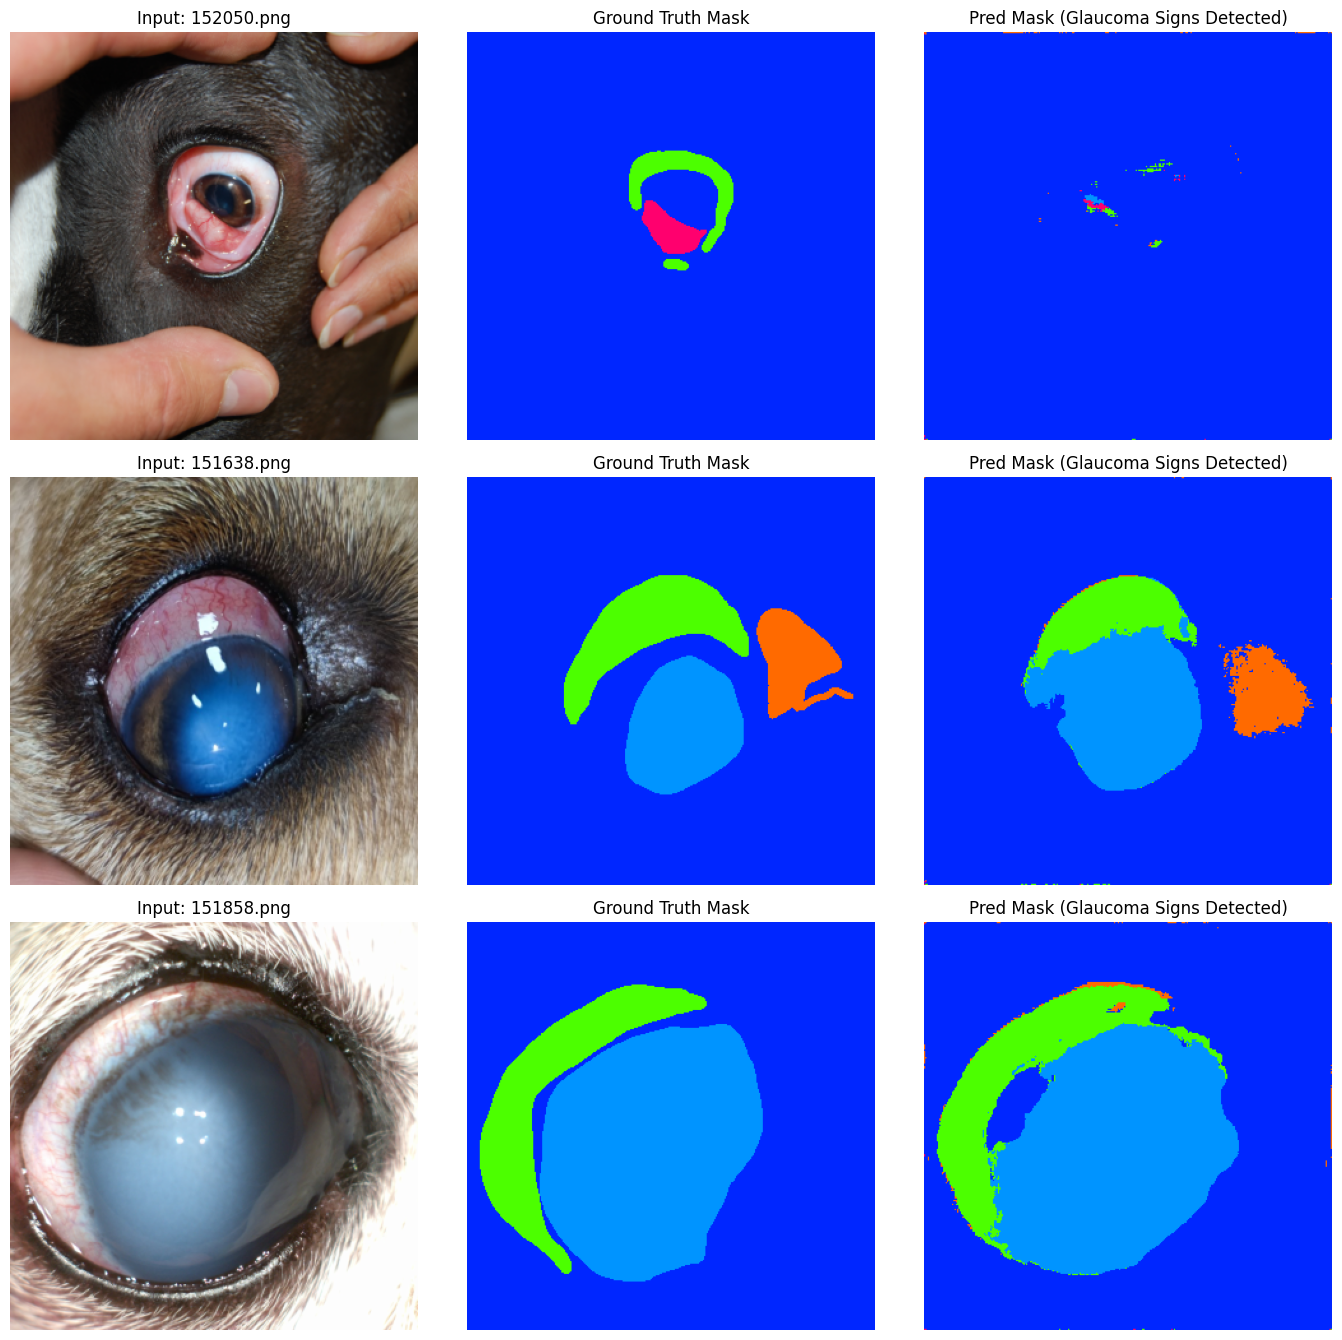

In [28]:
# Identify and load the top-performing model from your comparative results
best_model_name = df_comparison.sort_values(by="Test mIoU", ascending=False).index[0]


# Identify and load the model
# best_model_name = "CNN (ResNet34)"
best_cfg = EXPERIMENTS[best_model_name]
best_ckpt = f"best_{best_cfg['encoder'].replace('-', '_')}.pth"
print(f"Visualizing predictions using: {best_model_name} ({best_ckpt})")

eval_model = build_model(best_cfg["arch"], best_cfg["encoder"], num_classes=NUM_CLASSES)
eval_model.load_state_dict(torch.load(best_ckpt, weights_only=True))
eval_model.eval()

def decode_mask_to_rgb(mask_2d, palette=COLOR_PALETTE):
    """Converts a 2D class-index array (0-4) into an RGB image for plotting."""
    h, w = mask_2d.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in palette.items():
        rgb_mask[mask_2d == class_id] = color
    return rgb_mask

# Choose test indices
chosen_indices = [0, 1, 2]
batch = [test_loader.dataset[i] for i in chosen_indices]
imgs = torch.stack([item[0] for item in batch])
masks = torch.stack([item[1] for item in batch])

with torch.no_grad():
    logits = eval_model(imgs.to(device))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

num_to_display = len(chosen_indices)
fig, axes = plt.subplots(num_to_display, 3, figsize=(14, 4.5 * num_to_display))
if num_to_display == 1:
    axes = np.expand_dims(axes, 0)

for i in range(num_to_display):
    # Unnormalize image back to [0, 1] RGB
    img_disp = imgs[i].permute(1, 2, 0).cpu().numpy()
    img_disp = (img_disp * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img_disp = np.clip(img_disp, 0, 1)

    gt_rgb = decode_mask_to_rgb(masks[i].cpu().numpy())
    pred_rgb = decode_mask_to_rgb(preds[i])

    # Check for glaucoma markers (Class 1: Edema, Class 2: Episcleral congestion)
    has_edema = (preds[i] == 1).any()
    has_congestion = (preds[i] == 2).any()
    glaucoma_flag = "Glaucoma Signs Detected" if (has_edema or has_congestion) else "Normal / Non-Glaucomatous"

    orig_idx = chosen_indices[i]
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f"Input: {test_files[orig_idx]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt_rgb)
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_rgb)
    axes[i, 2].set_title(f"Pred Mask ({glaucoma_flag})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()